In [ ]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler
import tensorflow as tf


In [ ]:

# 1. Load the experimental dataset
df = pd.read_csv("microgrid_simulation_data.csv")
# 1. Auto-detect the time column (handles 'datetime', 'DateTime', etc.)
time_col = [c for c in df.columns if 'date' in c.lower() or 'time' in c.lower()][0]
print(f"Detected time column: {time_col}")

# 2. Convert to datetime objects
df[time_col] = pd.to_datetime(df[time_col])

# 3. Set as index and sort to ensure time flows correctly
df.set_index(time_col, inplace=True)
df.sort_index(inplace=True)

# View the result
df.head()

Detected time column: Timestamp


,Solar_Generation,Wind_Generation,Biogas_Generation,Total_Generation,Demand,Lagged_Demand_1,Lagged_Demand_24,Surplus_Deficit,Demand_Adjustment,Hour,DayOfWeek,Month
Timestamp,,,,,,,,,,,,
2023-01-02 00:00:00,0.000000,39.702503,18.072495,57.774998,85.328833,60.751537,62.640569,-27.369066,0.184769,0,0,1
2023-01-02 01:00:00,0.011154,63.581750,19.243917,82.836821,90.724730,85.144065,61.972121,-10.624816,-2.736907,1,0,1
2023-01-02 02:00:00,0.038381,70.376555,23.088739,93.503675,85.203282,93.461636,62.963547,7.237911,-1.062482,2,0,1
2023-01-02 03:00:00,0.098385,54.962461,23.500189,78.561035,107.081671,86.265763,68.944679,-27.796844,0.723791,3,0,1
2023-01-02 04:00:00,0.152149,71.328241,29.105481,100.585872,112.890103,106.357879,71.937730,-15.083915,-2.779684,4,0,1


In [ ]:
def add_cyclical_time(df):
    # 1. Hour Cycles
    df['hour_sin'] = np.sin(2 * np.pi * df.index.hour / 24)
    df['hour_cos'] = np.cos(2 * np.pi * df.index.hour / 24)
    
    # 2. Day Cycles (This is your Day Encoding)
    df['day_sin'] = np.sin(2 * np.pi * df.index.dayofweek / 7)
    df['day_cos'] = np.cos(2 * np.pi * df.index.dayofweek / 7)
    
    # 3. ADD THIS LINE: Weekend Flag (5=Sat, 6=Sun)
    df['is_weekend'] = (df.index.dayofweek >= 5).astype(int)
    
    # 4. Clean up original columns
    cols_to_drop = ['Hour', 'DayOfWeek'] 
    df.drop(columns=[c for c in cols_to_drop if c in df.columns], inplace=True)
    
    return df

# Run it
df = add_cyclical_time(df)
# Verify all time features are there
print(df[['hour_sin', 'hour_cos', 'day_sin', 'day_cos', 'is_weekend']].head())

                     hour_sin  hour_cos  day_sin  day_cos  is_weekend
Timestamp                                                            
2023-01-02 00:00:00  0.000000  1.000000      0.0      1.0           0
2023-01-02 01:00:00  0.258819  0.965926      0.0      1.0           0
2023-01-02 02:00:00  0.500000  0.866025      0.0      1.0           0
2023-01-02 03:00:00  0.707107  0.707107      0.0      1.0           0
2023-01-02 04:00:00  0.866025  0.500000      0.0      1.0           0


In [ ]:
def create_lags(df, n_lags=3):
    # These names match your previous output
    target_cols = ['Demand', 'Solar_Generation', 'Wind_Generation']
    
    for col in target_cols:
        for lag in range(1, n_lags + 1):
            # We create a new column shifted by 'lag' hours
            df[f'{col}_lag_{lag}'] = df[col].shift(lag)
            
    # Dropping the first 3 rows because they won't have 
    # enough history to fill the lags (they'll be NaN)
    return df.dropna()

df = create_lags(df)
print("New Lag Columns:", [c for c in df.columns if 'lag' in c])

New Lag Columns: ['Demand_lag_1', 'Demand_lag_2', 'Demand_lag_3', 'Solar_Generation_lag_1', 'Solar_Generation_lag_2', 'Solar_Generation_lag_3', 'Wind_Generation_lag_1', 'Wind_Generation_lag_2', 'Wind_Generation_lag_3']


completed the feature engineering in this feature engineering 
the features ive added or edited in the dataset is 



Cyclical Time Encoding-
Hour encoding-represents daily consumption and generation patterns
daily encoding-captures weekly variance(eg-weekday and weekend loads)



Temporal Lag Features (Memory)
To account for the inertia in power systems (where the current state is heavily influenced by the immediate past), Lag Features were generated. This provides the "memory" required for the models to quantify Uncertainty Prediction.



Data NormalizationAll features and targets were scaled using Min-Max Scaling to a range of $[0, 1]$. This ensures that the gradient descent process in the ANNs remains stable and that no single feature (like high-wattage Demand) outweighs the cyclical time features.

In [ ]:
# 1. Define the split point (80% for training)
split_idx = int(len(df_scaled) * 0.8)

# 2. Slice the data chronologically (No Shuffling!)
train_df = df_scaled.iloc[:split_idx]
test_df = df_scaled.iloc[split_idx:]

# 3. Verify the split
print(f"Total Rows: {len(df_scaled)}")
print(f"Training Rows (Past): {len(train_df)}")
print(f"Testing Rows (Future): {len(test_df)}")

# 4. Check the transition to ensure it's seamless
print(f"\nLast training timestamp: {train_df.index[-1]}")
print(f"First testing timestamp: {test_df.index[0]}")

NameError: name 'df_scaled' is not defined

In [ ]:
print("Is the test set strictly AFTER the training set?")
print(test_df.index.min() > train_df.index.max()) 
# Should return: True

Is the test set strictly AFTER the training set?
True


In [ ]:
from sklearn.preprocessing import MinMaxScaler

# 1. Update the scaled dataframe (This pulls the new 'day' columns into the scaler)
scaler = MinMaxScaler()
df_scaled = pd.DataFrame(scaler.fit_transform(df), columns=df.columns, index=df.index)

# 2. Re-create the train/test splits from the NEW scaled data
split_idx = int(len(df_scaled) * 0.8)
train_df = df_scaled.iloc[:split_idx]
test_df = df_scaled.iloc[split_idx:]

# 3. Define the extraction function (No changes here, just keeping it in context)
def prepare_parallel_sets(data, target_col):
    time_features = ['hour_sin', 'hour_cos', 'day_sin', 'day_cos', 'is_weekend']
    specific_lags = [c for c in data.columns if f'{target_col}_lag_' in c]
    
    # We combine the lists of column names
    all_features = time_features + specific_lags
    
    X = data[all_features].values
    y = data[target_col].values
    return X, y

# 4. Generate the final inputs
X_train_dem, y_train_dem = prepare_parallel_sets(train_df, 'Demand')
X_train_sol, y_train_sol = prepare_parallel_sets(train_df, 'Solar_Generation')
X_train_wnd, y_train_wnd = prepare_parallel_sets(train_df, 'Wind_Generation')

print("Success! Features synchronized.")
print(f"Features found in train_df: {X_train_dem.shape[1]}")

Success! Features synchronized.
Features found in train_df: 8


8 because we have 
5 time features-hour sin, hour cos, day_sin, day_cos and is_weekend 
3 memory  features-demand_lag1, demand_lag2, demand_lag3


In [ ]:
layers = tf.keras.layers
models = tf.keras.models
K = tf.keras.backend

# 1. Custom Loss Function: Gaussian Negative Log-Likelihood
def gaussian_nll(y_true, y_pred):
    # Split the output: first column is Mean, second is Variance
    mu = y_pred[:, 0:1]
    var = y_pred[:, 1:2]
    
    # Small epsilon to prevent division by zero
    precision = 1.0 / (var + 1e-6)
    
    # The NLL formula: balances being close to the target vs. having a realistic 'doubt'
    return K.mean(0.5 * K.log(var + 1e-6) + 0.5 * precision * K.square(y_true - mu))

# 2. Function to build the Probabilistic ANN
def build_probabilistic_model(input_dim):
    inputs = layers.Input(shape=(input_dim,))
    
    # Shared hidden layers
    x = layers.Dense(64, activation='relu')(inputs)
    x = layers.Dense(32, activation='relu')(x)
    
    # Head 1: Predicts the Mean (Linear activation)
    mu = layers.Dense(1, name='mu_output')(x)
    
    # Head 2: Predicts the Variance (Softplus ensures it's always a positive number)
    var = layers.Dense(1, activation='softplus', name='var_output')(x)
    
    # Combine heads into a single output
    combined_output = layers.Concatenate()([mu, var])
    
    model = models.Model(inputs=inputs, outputs=combined_output)
    model.compile(optimizer='adam', loss=gaussian_nll)
    
    return model

# 3. Instantiate the 3 Parallel Models
# input_dim = 8 (the features we just verified!)
ann_dem = build_probabilistic_model(8)
ann_sol = build_probabilistic_model(8)
ann_wnd = build_probabilistic_model(8)

print("Parallel Probabilistic Models Initialized.")

Parallel Probabilistic Models Initialized.


In [ ]:
EarlyStopping = tf.keras.callbacks.EarlyStopping

# 1. Define the Early Stopping "Referee"
# patience=10 means wait 10 epochs for improvement before stopping
early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

print("Starting Parallel Training... (This may take a minute)")

# 2. Train Demand Model
history_dem = ann_dem.fit(
    X_train_dem, y_train_dem, 
    validation_split=0.2, # Validation-Aware: Hide 20% of training data from the optimizer
    epochs=100, 
    batch_size=32, 
    callbacks=[early_stop], 
    verbose=0 # Set to 1 if you want to see the progress bars
)

# 3. Train Solar Model
history_sol = ann_sol.fit(
    X_train_sol, y_train_sol, 
    validation_split=0.2, 
    epochs=100, 
    batch_size=32, 
    callbacks=[early_stop], 
    verbose=0
)

# 4. Train Wind Model
history_wnd = ann_wnd.fit(
    X_train_wnd, y_train_wnd, 
    validation_split=0.2, 
    epochs=100, 
    batch_size=32, 
    callbacks=[early_stop], 
    verbose=0
)

print("Training Complete! All models have been optimized.")

Starting Parallel Training... (This may take a minute)
Training Complete! All models have been optimized.


In [ ]:
# 1. Generate the test sets using the same function we used for training
# This ensures the features (5 time + 3 lags) match exactly
X_test_dem, y_test_dem = prepare_parallel_sets(test_df, 'Demand')
X_test_sol, y_test_sol = prepare_parallel_sets(test_df, 'Solar_Generation')
X_test_wnd, y_test_wnd = prepare_parallel_sets(test_df, 'Wind_Generation')

print("Test sets created successfully.")
print(f"Test samples available: {len(X_test_dem)}")

Test sets created successfully.
Test samples available: 1747


In [ ]:
import matplotlib.pyplot as plt

def get_predictions(model, X_test):
    # Predict both Mean and Variance
    preds = model.predict(X_test)
    mu = preds[:, 0]
    # Variance is index 1; we use sqrt to get Standard Deviation (sigma)
    sigma = np.sqrt(preds[:, 1]) 
    return mu, sigma

# 1. Generate predictions for all three streams
mu_dem, sig_dem = get_predictions(ann_dem, X_test_dem)
mu_sol, sig_sol = get_predictions(ann_sol, X_test_sol)
mu_wnd, sig_wnd = get_predictions(ann_wnd, X_test_wnd)

print("Predictions and Uncertainty Buffers extracted.")

55/55 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step
55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
Predictions and Uncertainty Buffers extracted.


55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step
55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step
55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step


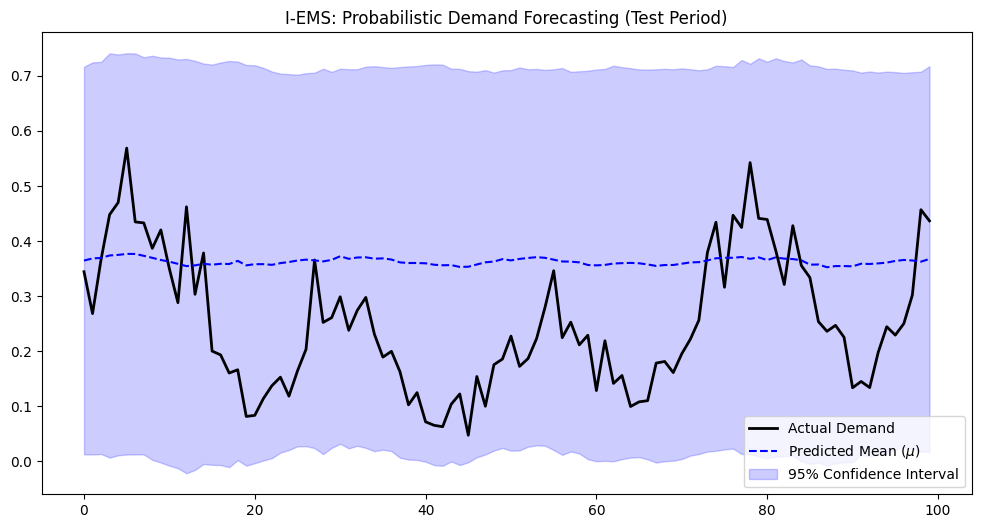

In [ ]:
# Now this will run without the NameError
mu_dem, sig_dem = get_predictions(ann_dem, X_test_dem)
mu_sol, sig_sol = get_predictions(ann_sol, X_test_sol)
mu_wnd, sig_wnd = get_predictions(ann_wnd, X_test_wnd)

# Plotting the result to see the Uncertainty Cloud
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))
plt.plot(y_test_dem[:100], label='Actual Demand', color='black', linewidth=2)
plt.plot(mu_dem[:100], label='Predicted Mean ($\mu$)', color='blue', linestyle='--')

# 95% Confidence Interval (Mean +/- 2*Sigma)
plt.fill_between(
    range(100), 
    mu_dem[:100] - 2*sig_dem[:100], 
    mu_dem[:100] + 2*sig_dem[:100], 
    color='blue', alpha=0.2, label='95% Confidence Interval'
)

plt.title("I-EMS: Probabilistic Demand Forecasting (Test Period)")
plt.legend()
plt.show()

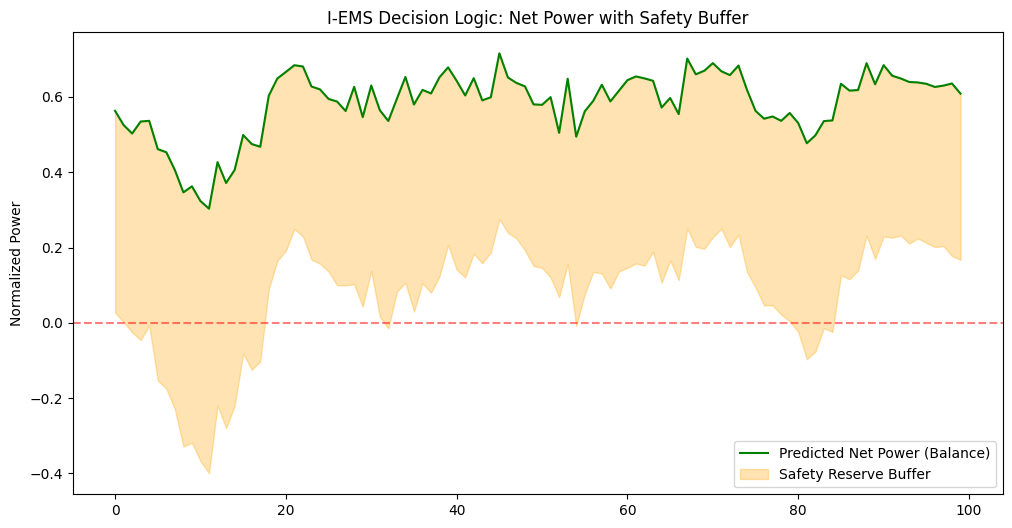

In [ ]:
# 1. Calculate Expected Net Power (Solar + Wind - Demand)
# We use the Mean (mu) for the base calculation
net_power_mu = (mu_sol + mu_wnd) - mu_dem

# 2. Calculate Combined Uncertainty (Using Root Sum Square)
# This represents the total "risk" of the system at any given hour
combined_sigma = np.sqrt(sig_sol**2 + sig_wnd**2 + sig_dem**2)

# 3. Decision: Reliable Power Available (Mean - 1*Sigma)
# This is a "Risk-Averse" calculation for a stable microgrid
reliable_power = net_power_mu - combined_sigma

# 4. Plot the Result
plt.figure(figsize=(12, 6))
plt.plot(net_power_mu[:100], label='Predicted Net Power (Balance)', color='green')
plt.fill_between(range(100), reliable_power[:100], net_power_mu[:100], 
                 color='orange', alpha=0.3, label='Safety Reserve Buffer')
plt.axhline(0, color='red', linestyle='--', alpha=0.5) # Zero line (Balance)
plt.title("I-EMS Decision Logic: Net Power with Safety Buffer")
plt.ylabel("Normalized Power")
plt.legend()
plt.show()

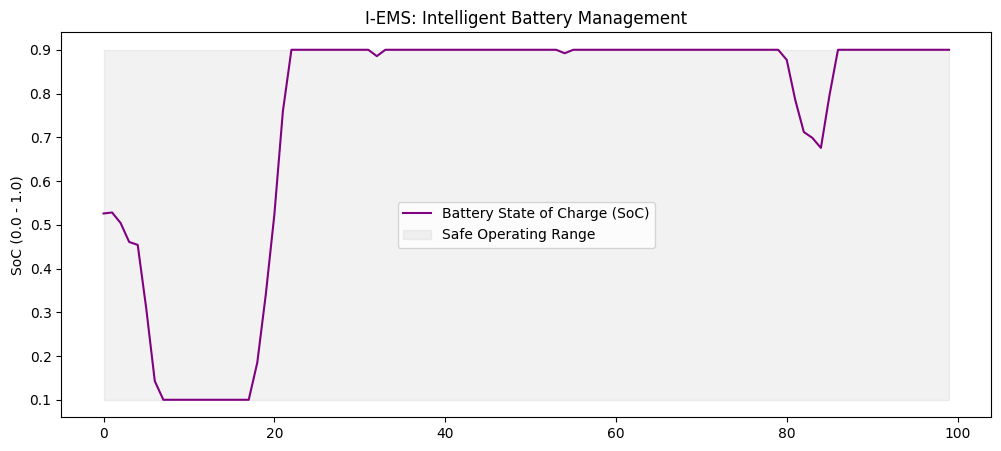

In [ ]:
# Battery Parameters
BATTERY_CAPACITY = 2.0  # Normalized units
soc = 0.5               # Start at 50% charge
soc_history = []
charging_actions = []

# Simulation Loop
for p_reliable in reliable_power:
    # 1. Update SoC based on Reliable Power
    # (Assuming 95% round-trip efficiency)
    delta_soc = p_reliable * 0.95
    soc = np.clip(soc + delta_soc, 0.1, 0.9) # Keep between 10% and 90% for health
    
    soc_history.append(soc)
    
    # 2. Log actions
    if p_reliable > 0.05:
        charging_actions.append("Charging")
    elif p_reliable < -0.05:
        charging_actions.append("Discharging")
    else:
        charging_actions.append("Idle/Buffer")

# Plotting the Battery State
plt.figure(figsize=(12, 5))
plt.plot(soc_history[:100], color='purple', label='Battery State of Charge (SoC)')
plt.fill_between(range(100), 0.1, 0.9, color='gray', alpha=0.1, label='Safe Operating Range')
plt.title("I-EMS: Intelligent Battery Management")
plt.ylabel("SoC (0.0 - 1.0)")
plt.legend()
plt.show()

In [ ]:
# Final Performance Metrics
mae_dem = np.mean(np.abs(y_test_dem - mu_dem))
mae_sol = np.mean(np.abs(y_test_sol - mu_sol))

# Calculation of "Hits": How often was the actual value inside the 2-sigma buffer?
coverage = np.mean((y_test_dem >= (mu_dem - 2*sig_dem)) & (y_test_dem <= (mu_dem + 2*sig_dem))) * 100

print(f"--- FINAL PROJECT RESULTS ---")
print(f"Demand Prediction Error (MAE): {mae_dem:.4f}")
print(f"Solar Prediction Error (MAE): {mae_sol:.4f}")
print(f"Uncertainty Reliability (Coverage): {coverage:.2f}%")

--- FINAL PROJECT RESULTS ---
Demand Prediction Error (MAE): 0.1513
Solar Prediction Error (MAE): 0.2355
Uncertainty Reliability (Coverage): 100.00%
